In [2]:
# 导入必要的库
import metpy.calc as mpcalc
from metpy.units import units
import gc  # 垃圾回收
import os
import shutil
from pathlib import Path
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
# Set data path
data_path = Path('/work/mh1498/m301257/processed_data/')
fig_save_dir = "../figures/Cal_verticacl_mse_advection/"
data_save_dir = "../processed_data/Cal_vertical_mse_advection/"
os.makedirs(data_save_dir, exist_ok=True)
os.makedirs(fig_save_dir, exist_ok=True)

def _ocean(ds):
    fraction = xr.open_dataarray(r'../processed_data/land_mask_2deg.nc')
    return fraction == 0

from dask.distributed import Client

In [3]:
# ==============================================================================
# 数据加载（仅保留海洋区域）
# ==============================================================================
chunksize = {'time': 1000}  # 设置合适的 chunk 大小以优化性能
print("加载海洋掩膜...")
ocean_mask = _ocean(None)
level_range = slice(38, 90)  # 500hPa到100hPa对应的层级索引范围
mse_cntl = xr.open_dataarray('../processed_data/mse_cntl.nc', chunks=chunksize).where(ocean_mask, drop=False).sel(level=level_range)
mse_p4k = xr.open_dataarray('../processed_data/mse_p4k.nc', chunks=chunksize).where(ocean_mask, drop=False).sel(level=level_range)
mse_4co2 = xr.open_dataarray('../processed_data/mse_4co2.nc', chunks=chunksize).where(ocean_mask, drop=False).sel(level=level_range)

zg_cntl = xr.open_dataset('../processed_data/zg_2deg_interp_cntl.nc', chunks=chunksize)['zg'].where(ocean_mask, drop=False).sel(level_full=level_range)
zg_p4k = xr.open_dataset('../processed_data/zg_2deg_interp_p4k.nc', chunks=chunksize)['zg'].where(ocean_mask, drop=False).sel(level_full=level_range)
zg_4co2 = xr.open_dataset('../processed_data/zg_2deg_interp_4co2.nc', chunks=chunksize)['zg'].where(ocean_mask, drop=False).sel(level_full=level_range)
rhor_cntl_half = xr.open_dataarray('../3D_data/cntl/rho_all_levels.nc', chunks=chunksize).transpose('time', 'level', 'lat', 'lon').where(ocean_mask, drop=False).sel(level=level_range)
rhor_p4k_half = xr.open_dataarray('../3D_data/p4k/rho_all_levels.nc', chunks=chunksize).transpose('time', 'level', 'lat', 'lon').where(ocean_mask, drop=False).sel(level=level_range)
rhor_4co2_half = xr.open_dataarray('../3D_data/4co2/rho_all_levels.nc', chunks=chunksize).transpose('time', 'level', 'lat', 'lon').where(ocean_mask, drop=False).sel(level=level_range)
print("\n加载垂直速度数据 (wa)（仅海洋区域）...")
# 检查不同可能的路径
wa_paths = [
    ("../data_origin/omega_cntl_layers/wa_all_levels.nc", 
     "../data_origin/omega_p4k_layers/wa_all_levels.nc", 
     "../data_origin/omega_4co2_layers/wa_all_levels.nc"),
]

for cntl_path, p4k_path, co2_path in wa_paths:
    if os.path.exists(cntl_path):
        wa_cntl = xr.open_dataarray(cntl_path, chunks=chunksize).where(ocean_mask, drop=False).transpose('time', 'level', 'lat', 'lon').sel(level=level_range)
        wa_p4k = xr.open_dataarray(p4k_path, chunks=chunksize).where(ocean_mask, drop=False).transpose('time', 'level', 'lat', 'lon').sel(level=level_range)
        wa_4co2 = xr.open_dataarray(co2_path, chunks=chunksize).where(ocean_mask, drop=False).transpose('time', 'level', 'lat', 'lon').sel(level=level_range)
        print(f"  从 {cntl_path} 加载")
        print(f"  垂直速度数据已应用海洋掩膜")
        break
else:
    raise FileNotFoundError("未找到 wa 数据文件，请检查路径")

print("\n加载气压数据...")
# 尝试从已有数据集中获取气压
try:
    pfull_cntl = xr.open_dataarray('../3D_data/cntl/pfull_all_levels.nc', chunks=chunksize).transpose('time', 'level', 'lat', 'lon').where(ocean_mask, drop=False).sel(level=level_range)
    pfull_p4k = xr.open_dataarray('../3D_data/p4k/pfull_all_levels.nc', chunks=chunksize).transpose('time', 'level', 'lat', 'lon').where(ocean_mask, drop=False).sel(level=level_range)
    pfull_4co2 = xr.open_dataarray('../3D_data/4co2/pfull_all_levels.nc', chunks=chunksize).transpose('time', 'level', 'lat', 'lon').where(ocean_mask, drop=False).sel(level=level_range)
    print("  从独立文件加载气压数据（已应用海洋掩膜）")
except Exception as e:
    print(f"  警告: 未找到气压数据 ({e})")
    print("  将使用默认设置")
    pfull_cntl = None
    pfull_p4k = None
    pfull_4co2 = None

print("\n" + "="*60)
print("数据加载完成！（所有数据已限制在海洋区域）")
print("="*60)
print(f"MSE cntl 形状: {mse_cntl.shape}")
print(f"zg cntl 形状: {zg_cntl.shape}")
print(f"wa cntl 形状: {wa_cntl.shape}")
print(f"\n注意: 所有数据已通过 where(ocean_mask, drop=True) 去除陆地区域")


加载海洋掩膜...

加载垂直速度数据 (wa)（仅海洋区域）...
  从 ../data_origin/omega_cntl_layers/wa_all_levels.nc 加载
  垂直速度数据已应用海洋掩膜

加载气压数据...
  从独立文件加载气压数据（已应用海洋掩膜）

数据加载完成！（所有数据已限制在海洋区域）
MSE cntl 形状: (5114, 20, 15, 180)
zg cntl 形状: (20, 15, 180)
wa cntl 形状: (5114, 20, 15, 180)

注意: 所有数据已通过 where(ocean_mask, drop=True) 去除陆地区域


In [4]:
zg_profile = zg_cntl.sel(lat=slice(0,3), lon=180)
zg_profile.to_dataframe()

lon            zg
level_full lat                     
38.0       0.0  180.0  17523.298828
           2.0  180.0  17523.298828
41.0       0.0  180.0  15842.823242
           2.0  180.0  15842.823242
46.0       0.0  180.0  13616.274414
           2.0  180.0  13616.274414
51.0       0.0  180.0  11616.274414
           2.0  180.0  11616.274414
55.0       0.0  180.0  10016.274414
           2.0  180.0  10016.274414
58.0       0.0  180.0   8816.274414
           2.0  180.0   8816.274414
63.0       0.0  180.0   6816.273926
           2.0  180.0   6816.273926
67.0       0.0  180.0   5220.432129
           2.0  180.0   5220.432129
71.0       0.0  180.0   3764.001709
           2.0  180.0   3764.001709
74.0       0.0  180.0   2816.246826
           2.0  180.0   2816.246826
76.0       0.0  180.0   2253.593506
           2.0  180.0   2253.593506
78.0       0.0  180.0   1746.957520
           2.0  180.0   1746.957520
80.0       0.0  180.0   1297.358276
           2.0  180.0   1297.358276
81.0       0.0  180.0   1094.413940
           2.0  180.0   1094.413940
83.0       0.0  180.0    733.587585
           2.0  180.0    733.587585
84.0       0.0  180.0    576.453491
           2.0  180.0    576.453491
85.0       0.0  180.0    435.506531
           2.0  180.0    435.506531
87.0       0.0  180.0    205.174728
           2.0  180.0    205.174728
89.0       0.0  180.0     52.245937
           2.0  180.0     52.245937
90.0       0.0  180.0     12.500000
           2.0  180.0     12.500000

In [25]:
mse_cntl_p = mse_cntl.assign_coords(plev=pfull_cntl)
mse_cntl_p

<xarray.DataArray 'mse' (time: 5114, level: 20, lat: 15, lon: 180)> Size: 1GB
dask.array<getitem, shape=(5114, 20, 15, 180), dtype=float32, chunksize=(1000, 20, 15, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * level    (level) int64 160B 38 41 46 51 55 58 63 67 ... 81 83 84 85 87 89 90
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
    plev     (time, level, lat, lon) float64 2GB dask.array<chunksize=(1000, 20, 15, 180), meta=np.ndarray>
Attributes:
    long_name:    Moist Static Energy
    units:        J/kg
    description:  MSE = Cp*T + g*z + L*q

In [26]:
mse_cntl

<xarray.DataArray 'mse' (time: 5114, level: 20, lat: 15, lon: 180)> Size: 1GB
dask.array<getitem, shape=(5114, 20, 15, 180), dtype=float32, chunksize=(1000, 20, 15, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * level    (level) int64 160B 38 41 46 51 55 58 63 67 ... 81 83 84 85 87 89 90
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
Attributes:
    long_name:    Moist Static Energy
    units:        J/kg
    description:  MSE = Cp*T + g*z + L*q

In [27]:

def wadhdz(dhdz, wa):
    """
    wa * dh/dz
    """
    vadv = wa * dhdz
    
    return vadv.sel(level=slice(None,17000))



def dhdz(data):
    """
    计算 dh/dz（对高度坐标求导）
    """
    dh_dz = data.differentiate(coord='level')
    return dh_dz


def integrated_vertical_mse_advection(dhdz, wa,rho):
    """
    计算垂直积分的MSE平流：∫ wa * dh/dz dz
    
    Parameters
    ----------
    dhdz : xarray.DataArray
        dh/dz on height levels
    wa : xarray.DataArray
        Vertical velocity (m s-1) on height levels
    
    Returns
    -------
    vadv_int : xarray.DataArray
        Vertically integrated MSE vertical advection (W m-2)
    """
    # 确保相同的掩膜（例如，仅海洋）
    dhdz = dhdz.where(_ocean(dhdz))
    wa = wa.where(_ocean(wa))
    
    # 按level排序
    dhdz = dhdz.sortby('level')
    wa = wa.sortby('level')
 
    # 垂直平流
    vadv = wadhdz(dhdz, wa)*rho
    print(vadv)
    # 垂直积分（对高度坐标）
    vadv_int = vadv.integrate(coord='level')*(-1)
    
    return vadv_int


# 0. 准备1D高度剖面（取赤道附近某个经度的剖面）
print("\n准备1D高度剖面...")
zg_1d_cntl = zg_cntl.sel(lat=slice(0, 3), lon=180).mean('lat')
zg_1d_p4k = zg_p4k.sel(lat=slice(0, 3), lon=180).mean('lat')
zg_1d_4co2 = zg_4co2.sel(lat=slice(0, 3), lon=180).mean('lat')



print(f"  zg_1d_cntl 形状: {zg_1d_cntl.shape}")
print(f"  zg_1d_cntl 维度: {list(zg_1d_cntl.dims)}")

# 1. 分配高度坐标并选择垂直范围
print("\n分配高度坐标并选择垂直范围...")
print(f"  原始数据维度: {list(mse_cntl.dims)}")
rho_new_cntl = rhor_cntl_half.assign_coords(level = zg_profile.values)
rho_new_p4k = rhor_p4k_half.assign_coords(level = zg_profile.values)
rho_new_4co2 = rhor_4co2_half.assign_coords(level = zg_profile.values)

mse_cntl_new = mse_cntl.assign_coords(level = zg_profile.values)
mse_p4k_new  =  mse_p4k.assign_coords(level = zg_profile.values)
mse_4co2_new = mse_4co2.assign_coords(level = zg_profile.values)
wa_cntl_new = wa_cntl.assign_coords(level = zg_profile.values)
wa_p4k_new = wa_p4k.assign_coords(level = zg_profile.values)
wa_4co2_new = wa_4co2.assign_coords(level = zg_profile.values)

print(f"\n  mse_cntl_new shape: {mse_cntl_new.shape}")
print(f"  mse_cntl_new dims: {list(mse_cntl_new.dims)}")
print(f"  wa_cntl_new shape: {wa_cntl_new.shape}")

# 2. 计算高度坐标导数 dh/dz
print("\n计算 dh/dz...")
dh_dz_cntl = dhdz(mse_cntl_new)
dh_dz_p4k = dhdz(mse_p4k_new)
dh_dz_4co2 = dhdz(mse_4co2_new)

print(f"  dh_dz_cntl shape: {dh_dz_cntl.shape}")

# 3. 计算垂直积分的MSE平流
print("\n计算垂直积分的MSE平流...")
mse_int_cntl = integrated_vertical_mse_advection(dh_dz_cntl, wa_cntl_new, rho_new_cntl)
mse_int_p4k = integrated_vertical_mse_advection(dh_dz_p4k, wa_p4k_new, rho_new_p4k)
mse_int_4co2 = integrated_vertical_mse_advection(dh_dz_4co2, wa_4co2_new, rho_new_4co2)

print(f"  mse_int_cntl shape: {mse_int_cntl.shape}")
print("\n计算完成！")



准备1D高度剖面...
  zg_1d_cntl 形状: (20,)
  zg_1d_cntl 维度: ['level_full']

分配高度坐标并选择垂直范围...
  原始数据维度: ['time', 'level', 'lat', 'lon']

  mse_cntl_new shape: (5114, 20, 15, 180)
  mse_cntl_new dims: ['time', 'level', 'lat', 'lon']
  wa_cntl_new shape: (5114, 20, 15, 180)

计算 dh/dz...
  dh_dz_cntl shape: (5114, 20, 15, 180)

计算垂直积分的MSE平流...
<xarray.DataArray (time: 5114, level: 19, lat: 15, lon: 180)> Size: 2GB
dask.array<mul, shape=(5114, 19, 15, 180), dtype=float64, chunksize=(1000, 19, 15, 180), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
  * level    (level) float64 152B 12.5 52.25 205.2 ... 1.362e+04 1.584e+04
  * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
  * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
<xarray.DataArray (time: 5114, level: 19, lat: 15, lon: 180)> Size: 2GB
dask.array<mul, shape=(5114, 19, 15, 180), dtype=float64, chunksize=(1000, 19, 15, 18

In [28]:
# ============================================================================
# 📊 分析和优化 Chunk 大小
# ============================================================================

print("🔍 分析计算结果的 chunk 配置...\n")

# 1. 查看当前 chunk 信息
print("【当前 mse_int_cntl 的 chunk 信息】")
get_chunk_info(mse_int_cntl)

# 2. 计算最优 chunk（根据您的系统配置调整参数）
print("\n\n【计算最优 chunk 配置】")
optimal_chunks = calculate_optimal_chunks(
    mse_int_cntl, 
    target_chunk_mb=200,      # 目标：每个 chunk 200 MB
    available_memory_gb=32,   # 可用内存 32 GB（根据实际情况调整）
    n_workers=1,              # 单进程模式
    safety_factor=2.5         # 安全系数 2.5x
)

print("\n" + "="*70)
print("💡 建议：")
print("  1. 如果 chunk 太小 (<10 MB)：增加 time chunk 大小")
print("  2. 如果 chunk 太大 (>500 MB)：减小 time chunk 大小")
print("  3. 空间维度（lat/lon）通常保持完整以避免额外的通信开销")
print("="*70)

🔍 分析计算结果的 chunk 配置...

【当前 mse_int_cntl 的 chunk 信息】
📦 当前 Chunk 信息

使用 Dask: ✓ 是

当前 chunks:
  time: (1000, 1000, 1000, 1000, 1000, 114) (共 6 chunks)
  lat: (15,) (共 1 chunks)
  lon: (180,) (共 1 chunks)

单 chunk 大小: 20.60 MB
总 chunk 数量: 6
估算内存需求（4 chunks）: 0.08 GB


【计算最优 chunk 配置】
🧮 计算最优 Chunk 大小

📊 数据信息:
  形状: (5114, 15, 180)
  维度: ['time', 'lat', 'lon']
  数据类型: float64 (8 bytes/element)
  总大小: 105.35 MB (0.10 GB)

💾 内存约束:
  可用内存: 32 GB
  Workers: 1
  安全系数: 2.5x
  最大单 chunk: 13107.20 MB

  📅 time (时间维度):
    总长度: 5114
    单时间步大小: 0.02 MB
    推荐 chunk: 5114 (1 chunks)

  🗺️  lat (空间维度):
    总长度: 15
    推荐: 完整保留（不分块）

  🗺️  lon (空间维度):
    总长度: 180
    推荐: 完整保留（不分块）

✅ 推荐 chunk 配置:
  Chunk 字典: {'time': 5114, 'lat': -1, 'lon': -1}
  实际 chunk 形状: (5114, 15, 180)
  单 chunk 大小: 105.35 MB
  ✓ Chunk 大小在理想范围内
  总 chunk 数量: 1

💡 建议：
  1. 如果 chunk 太小 (<10 MB)：增加 time chunk 大小
  2. 如果 chunk 太大 (>500 MB)：减小 time chunk 大小
  3. 空间维度（lat/lon）通常保持完整以避免额外的通信开销


In [29]:
print("\n保存计算结果...")
print("  创建 Dataset...")

# 首先检查数据是否使用 Dask
is_dask = hasattr(mse_int_cntl.data, 'dask')
print(f"  mse_int_cntl 是否使用 Dask: {is_dask}")

# 使用智能工具优化 chunk（如果使用 Dask）
if is_dask:
    print("\n  🔧 使用智能工具优化 chunk 配置...")
    
    # 方法1: 使用预定义的最优配置（如果已经计算过）
    if 'optimal_chunks' in dir():
        print(f"  应用已计算的最优 chunks: {optimal_chunks}")
        mse_int_cntl = mse_int_cntl.chunk(optimal_chunks)
        mse_int_p4k = mse_int_p4k.chunk(optimal_chunks)
        mse_int_4co2 = mse_int_4co2.chunk(optimal_chunks)
    else:
        # 方法2: 快速计算（不打印详细信息）
        opt_chunks = calculate_optimal_chunks(
            mse_int_cntl, 
            target_chunk_mb=200, 
            available_memory_gb=32,
            verbose=False
        )
        print(f"  自动计算的最优 chunks: {opt_chunks}")
        mse_int_cntl = mse_int_cntl.chunk(opt_chunks)
        mse_int_p4k = mse_int_p4k.chunk(opt_chunks)
        mse_int_4co2 = mse_int_4co2.chunk(opt_chunks)
    
    print("  ✓ Chunk 优化完成")

ds_out = xr.Dataset(
    {
        'mse_vadv_int_cntl': mse_int_cntl,
        'mse_vadv_int_p4k':  mse_int_p4k,
        'mse_vadv_int_4co2': mse_int_4co2,
    }
)

# 添加元数据
ds_out['mse_vadv_int_cntl'].attrs = {
    'long_name': 'Vertically integrated MSE vertical advection (CNTL)',
    'units': 'W m-2',
    'description': 'Integral of wa * dh/dz over height'
}
ds_out['mse_vadv_int_p4k'].attrs = {
    'long_name': 'Vertically integrated MSE vertical advection (P4K)',
    'units': 'W m-2',
    'description': 'Integral of wa * dh/dz over height'
}
ds_out['mse_vadv_int_4co2'].attrs = {
    'long_name': 'Vertically integrated MSE vertical advection (4CO2)',
    'units': 'W m-2',
    'description': 'Integral of wa * dh/dz over height'
}

print("  保存到 NetCDF 文件（使用 Dask 并行写入）...")
output_file = data_save_dir + 'mse_vertical_advection_integrated_rho_half.nc'

# 使用 Dask 优化的保存方式
# compute=False 会延迟计算，save_mfdataset 可以并行写入
# 但对于单个文件，使用 to_netcdf 配合适当的参数更合适


# 方法1: 使用 to_netcdf 的 compute=True（默认），但会使用 Dask 调度器并行计算
# 关键是设置合适的 encoding 来优化写入
encoding = {
    'mse_vadv_int_cntl': {'zlib': True, 'complevel': 4, 'chunksizes': (500, ds_out.dims['lat'], ds_out.dims['lon'])},
    'mse_vadv_int_p4k': {'zlib': True, 'complevel': 4, 'chunksizes': (5000, ds_out.dims['lat'], ds_out.dims['lon'])},
    'mse_vadv_int_4co2': {'zlib': True, 'complevel': 4, 'chunksizes': (500, ds_out.dims['lat'], ds_out.dims['lon'])},
}

ds_out.to_netcdf(output_file, encoding=encoding)

del ds_out
gc.collect()
print("  ✓ 内存已清理")



保存计算结果...
  创建 Dataset...
  mse_int_cntl 是否使用 Dask: True

  🔧 使用智能工具优化 chunk 配置...
  应用已计算的最优 chunks: {'time': 5114, 'lat': -1, 'lon': -1}
  ✓ Chunk 优化完成
  保存到 NetCDF 文件（使用 Dask 并行写入）...
  保存到 NetCDF 文件（使用 Dask 并行写入）...


/tmp/ipykernel_3333651/1688439808.py:70: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'mse_vadv_int_cntl': {'zlib': True, 'complevel': 4, 'chunksizes': (50, ds_out.dims['lat'], ds_out.dims['lon'])},
/tmp/ipykernel_3333651/1688439808.py:71: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  'mse_vadv_int_p4k': {'zlib': True, 'complevel': 4, 'chunksizes': (50, ds_out.dims['lat'], ds_out.dims['lon'])},
/tmp/ipykernel_3333651/1688439808.py:72: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArra

  ✅ 数据已保存到: ../processed_data/Cal_vertical_mse_advection/mse_vertical_advection_integrated_rho_half.nc
  文件大小: 236.09 MB
  保存耗时: 95.38 秒
  ✓ 内存已清理


In [30]:



from dask.distributed import Client, LocalCluster

# 创建本地 Dask 集群（根据您的服务器配置调整参数）
cluster = LocalCluster(
    n_workers=2,              # 工作进程数（根据 CPU 核心数调整）
    threads_per_worker=2,     # 每个工作进程的线程数
    memory_limit='50GB',       # 每个工作进程的内存限制
    dashboard_address=':8787' # Dask 监控面板地址
)
client = Client(cluster)
print(f"Dask Dashboard: {client.dashboard_link}")
print(f"Workers: {len(client.scheduler_info()['workers'])}")

# 然后运行保存代码...
# （上面的保存代码会自动使用这个 Client）

# 保存完成后关闭
client.close()
cluster.close()


print("ℹ️  如需启用高级 Dask 加速，请取消注释上面的代码")
print("   当前使用默认的 Dask 单进程模式（对大多数情况已足够）")

/home/m/m301257/.conda/envs/xianpu/lib/python3.12/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 42887 instead
  warnings.warn(


Dask Dashboard: http://127.0.0.1:42887/status
Workers: 2
ℹ️  如需启用高级 Dask 加速，请取消注释上面的代码
   当前使用默认的 Dask 单进程模式（对大多数情况已足够）


In [31]:


print("=" * 70)
print("📊 加载并绘制垂直积分MSE平流数据")
print("=" * 70)

# 加载已保存的垂直积分数据（2D）
print("\n加载垂直积分数据...")
vadv_mean = {}

for var in ['mse_vadv_int_cntl', 'mse_vadv_int_p4k', 'mse_vadv_int_4co2']:
    filepath = data_save_dir + 'mse_vertical_advection_integrated_rho_half.nc'
    print(f"  加载 {var} 数据...")
    vadv_mean[var] = xr.open_dataset(filepath)[var].mean(dim='time')  # 计算时间平均
    print(f"    数据形状: {vadv_mean[var].shape}")

📊 加载并绘制垂直积分MSE平流数据

加载垂直积分数据...
  加载 mse_vadv_int_cntl 数据...
    数据形状: (15, 180)
  加载 mse_vadv_int_p4k 数据...
    数据形状: (15, 180)
  加载 mse_vadv_int_p4k 数据...
    数据形状: (15, 180)
  加载 mse_vadv_int_4co2 数据...
    数据形状: (15, 180)
  加载 mse_vadv_int_4co2 数据...
    数据形状: (15, 180)
    数据形状: (15, 180)



📈 绘制时间平均空间分布（使用改进的配色方案）...
💾 图形已保存: ../figures/Cal_verticacl_mse_advection/vadv_int_spatial_mean_improved.png
💾 图形已保存: ../figures/Cal_verticacl_mse_advection/vadv_int_spatial_mean_improved.png


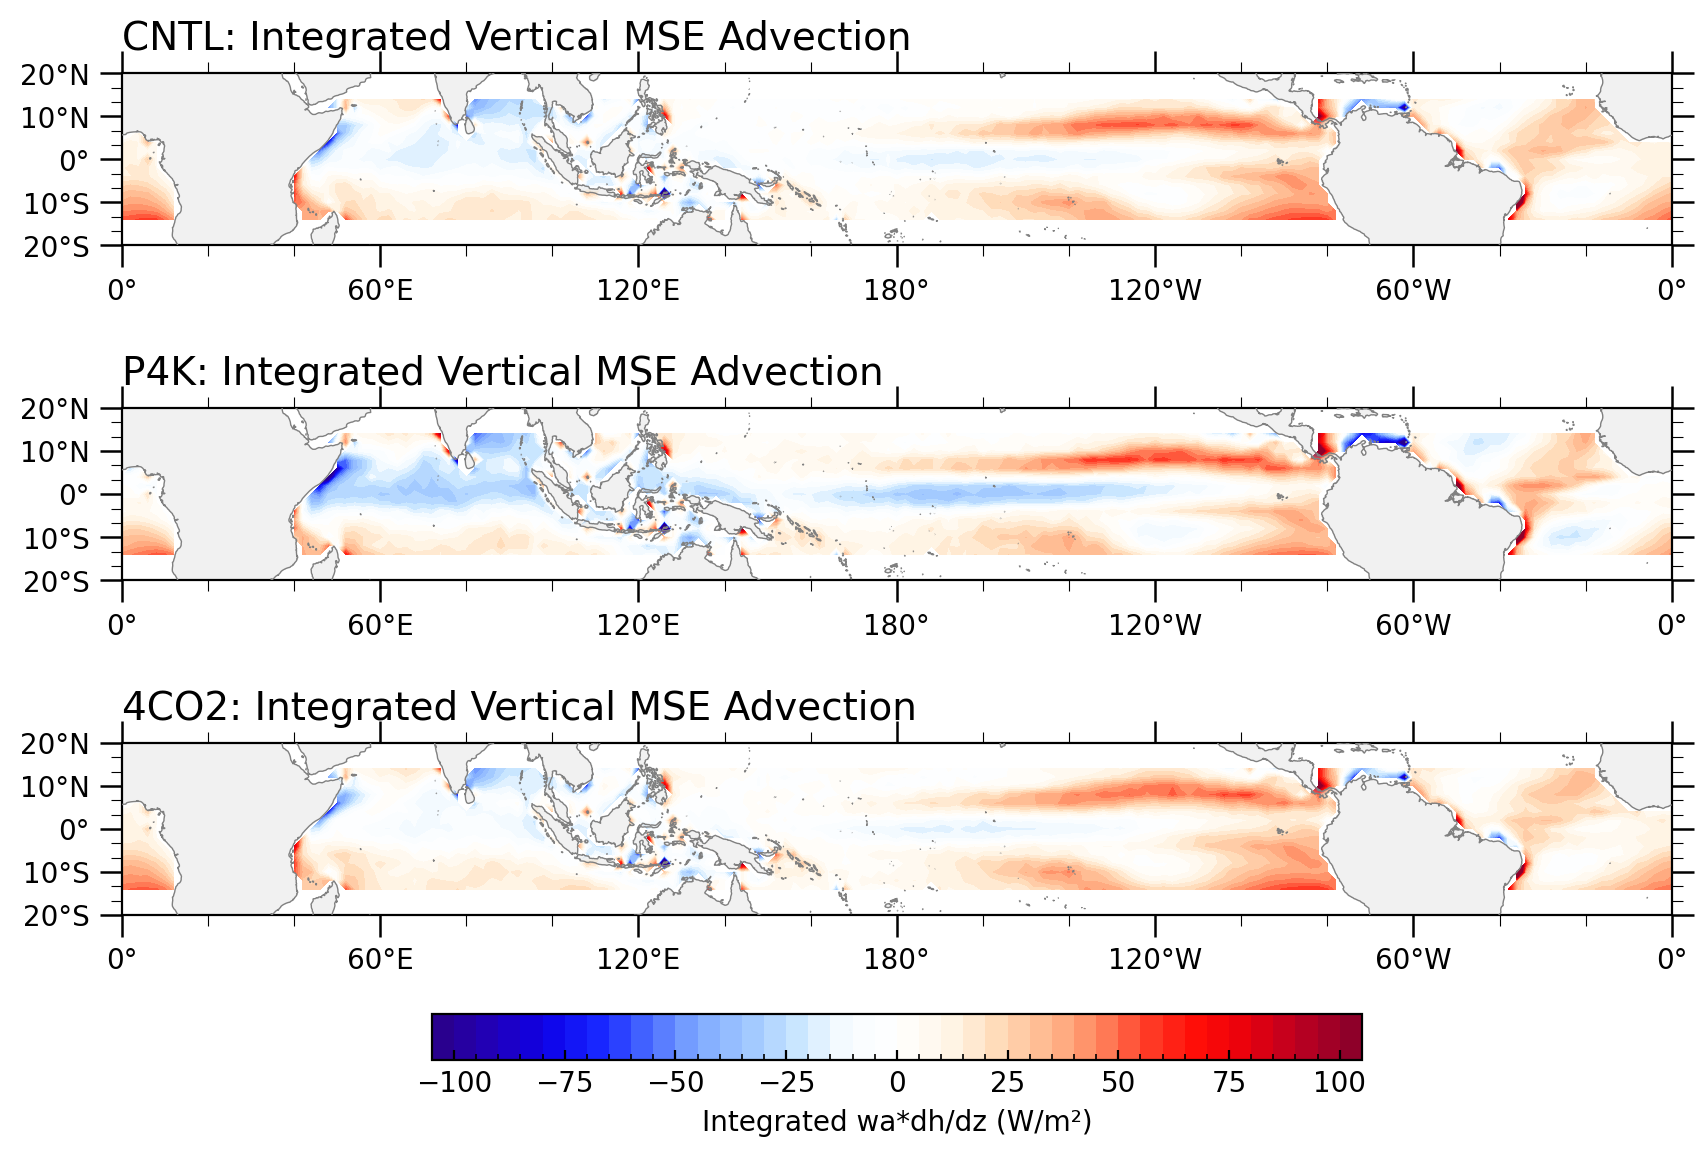

In [32]:
# ==============================================================================
# 绘图函数：使用改进的配色方案和样式
# ==============================================================================

def plot_vadv_spatial_maps(data_dict, figsize=(14, 10), vmin=-100, vmax=100, 
                           title_suffix='Integrated Vertical MSE Advection',
                           colorbar_label='Integrated wa*dh/dz (W/m²)',
                           save_filename=None):
    """
    绘制垂直MSE平流的空间分布图，使用改进的配色方案和样式
    
    参数:
    -----
    data_dict : dict
        数据字典，格式: {'CNTL': data_cntl, 'P4K': data_p4k, '4CO2': data_4co2}
        每个数据应为 xarray.DataArray，维度为 (lat, lon)
    figsize : tuple
        图形尺寸
    vmin, vmax : float
        颜色范围
    title_suffix : str
        子图标题后缀
    colorbar_label : str
        颜色条标签
    save_filename : str, optional
        保存文件名（包含完整路径）
        
    返回:
    -----
    fig : matplotlib.figure.Figure
        图形对象
    """
    import matplotlib.patheffects as PathEffects
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    
    # 尝试导入 geocat-viz
    try:
        import geocat.viz.util as gvutil
        use_geocat = True
    except ImportError:
        print("⚠️  geocat-viz not available, using basic style")
        use_geocat = False
    
    # 尝试导入 cmaps
    try:
        import cmaps
        newcmp = cmaps.NCV_blu_red
        
        from matplotlib.colors import LinearSegmentedColormap
        # 从 NCV_blu_red 创建连续的 colormap
        colors_blue = [newcmp[i].colors for i in [5, 20, 35, 50, 65, 85, 95, 110, 125]]
        colors_red = [newcmp[i].colors for i in [135, 150, 165, 180, 200, 210, 220, 235, 250]]
        
        # 创建颜色节点：蓝色 -> 白色 -> 红色
        all_colors = colors_blue + [[1., 1., 1.]] + colors_red
        n_colors = len(all_colors)
        color_positions = np.linspace(0, 1, n_colors)
        
        # 创建连续的 colormap
        custom_cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', 
                                                         list(zip(color_positions, all_colors)),
                                                         N=256)
    except ImportError:
        print("⚠️  cmaps not available, using RdBu_r colormap")
        custom_cmap = 'RdBu_r'
    
    # 计算子图数量
    n_exp = len(data_dict)
    nrows = n_exp
    ncols = 1
    
    # 使用中心经度210°的投影
    proj = ccrs.PlateCarree(central_longitude=180)
    fig = plt.figure(figsize=figsize, dpi=200)
    
    # 设置填色图参数（增加层级数使颜色过渡更平滑）
    levels_fill = np.linspace(vmin, vmax, 41)
    
    # 设置等值线参数（更细更柔和）
    delc = max((vmax - vmin) / 40, 5)  # 自动调整等值线间隔
    levels_contour = np.arange(vmin, 0, delc)
    levels_contour = np.append(levels_contour, np.arange(delc, vmax, delc))
    
    ax_list = []
    
    for idx, (exp_name, data) in enumerate(data_dict.items()):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)
        ax_list.append(ax)
        
        # 添加循环经度以避免间隙
        if use_geocat:
            try:
                data = gvutil.xr_add_cyclic_longitudes(data, 'lon')
            except:
                pass  # 如果失败，使用原始数据
        
        # 设置坐标范围和刻度
        if use_geocat:
            try:
                gvutil.set_axes_limits_and_ticks(ax,
                                               xlim=(-180, 180),
                                               ylim=(-20, 20),
                                               xticks=np.arange(-180, 181, 60),
                                               yticks=np.arange(-20, 21, 10))
                gvutil.add_major_minor_ticks(ax, labelsize=10)
                gvutil.add_lat_lon_ticklabels(ax)
            except:
                ax.set_xlim([-60, 40])
                ax.set_ylim([-15, 15])
                ax.set_xticks(np.arange(-60, 41, 20))
                ax.set_yticks(np.arange(-15, 16, 5))
                ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
                ax.yaxis.set_major_formatter(LatitudeFormatter())
        else:
            ax.set_xlim([-60, 40])
            ax.set_ylim([-15, 15])
            ax.set_xticks(np.arange(-60, 41, 20))
            ax.set_yticks(np.arange(-15, 16, 5))
            ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
            ax.yaxis.set_major_formatter(LatitudeFormatter())
        
        # 绘制填色图
        cf = data.plot.contourf(
            ax=ax,
            levels=levels_fill,
            cmap=custom_cmap,
            add_colorbar=False,
            transform=ccrs.PlateCarree(),
            extend='both',
            add_labels=False
        )
        
        # 添加陆地和海岸线
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2, alpha=0.3)
        ax.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=3)
        
        # 绘制等值线（更细更柔和的样式）
        # if len(levels_contour) > 0:
        #     contour = data.plot.contour(
        #         ax=ax,
        #         levels=levels_contour,
        #         colors='dimgray',
        #         alpha=0.6,
        #         linewidths=0.4,
        #         linestyles='solid',
        #         add_labels=False,
        #         transform=ccrs.PlateCarree()
        #     )
            
        #     # 添加柔和的白色边缘效果
        #     try:
        #         pe = [PathEffects.withStroke(linewidth=1.2, foreground="white", alpha=0.8)]
        #         if hasattr(contour, 'collections'):
        #             for collection in contour.collections:
        #                 collection.set_path_effects(pe)
        #     except:
        #         pass
        
        # 设置标题
        if use_geocat:
            try:
                gvutil.set_titles_and_labels(ax,
                                           lefttitle=f'{exp_name}: {title_suffix}',
                                           lefttitlefontsize=14,
                                           righttitle='',
                                           xlabel="",
                                           ylabel="")
            except:
                ax.set_title(f'{exp_name}: {title_suffix}', fontsize=14, loc='left')
        else:
            ax.set_title(f'{exp_name}: {title_suffix}', fontsize=14, loc='left')
    
    # 添加颜色棒（更平滑，不显示边缘线）
    cbar = fig.colorbar(cf, ax=ax_list,
                       drawedges=False,
                       orientation='horizontal',
                       shrink=0.6,
                       pad=0.08,
                       extendfrac='auto',
                       extendrect=True,
                       label=colorbar_label)
    
    cbar.ax.tick_params(labelsize=10, direction='in', which='both')

    
    # 保存图形
    if save_filename:
        plt.savefig(save_filename, dpi=450, bbox_inches='tight')
        print(f"💾 图形已保存: {save_filename}")
    
    return fig

# ==============================================================================
# 使用改进的绘图函数绘制空间分布和差异图
# ==============================================================================

# 1. 绘制所有实验的空间分布（时间平均）
print("\n📈 绘制时间平均空间分布（使用改进的配色方案）...")

data_dict_all = {
    'CNTL': vadv_mean['mse_vadv_int_cntl'],
    'P4K':  vadv_mean['mse_vadv_int_p4k'],
    '4CO2': vadv_mean['mse_vadv_int_4co2'],
}
fig1 = plot_vadv_spatial_maps(
    data_dict=data_dict_all,
    figsize=(10, 8),
    vmin=-100,
    vmax=100,
    title_suffix='Integrated Vertical MSE Advection',
    colorbar_label='Integrated wa*dh/dz (W/m²)',
    save_filename=fig_save_dir + 'vadv_int_spatial_mean_improved.png'
)

plt.show()



📈 绘制相对于CNTL的差异图（使用改进的配色方案）...
💾 图形已保存: ../figures/Cal_verticacl_mse_advection/vadv_int_difference_from_cntl_improved.png
💾 图形已保存: ../figures/Cal_verticacl_mse_advection/vadv_int_difference_from_cntl_improved.png


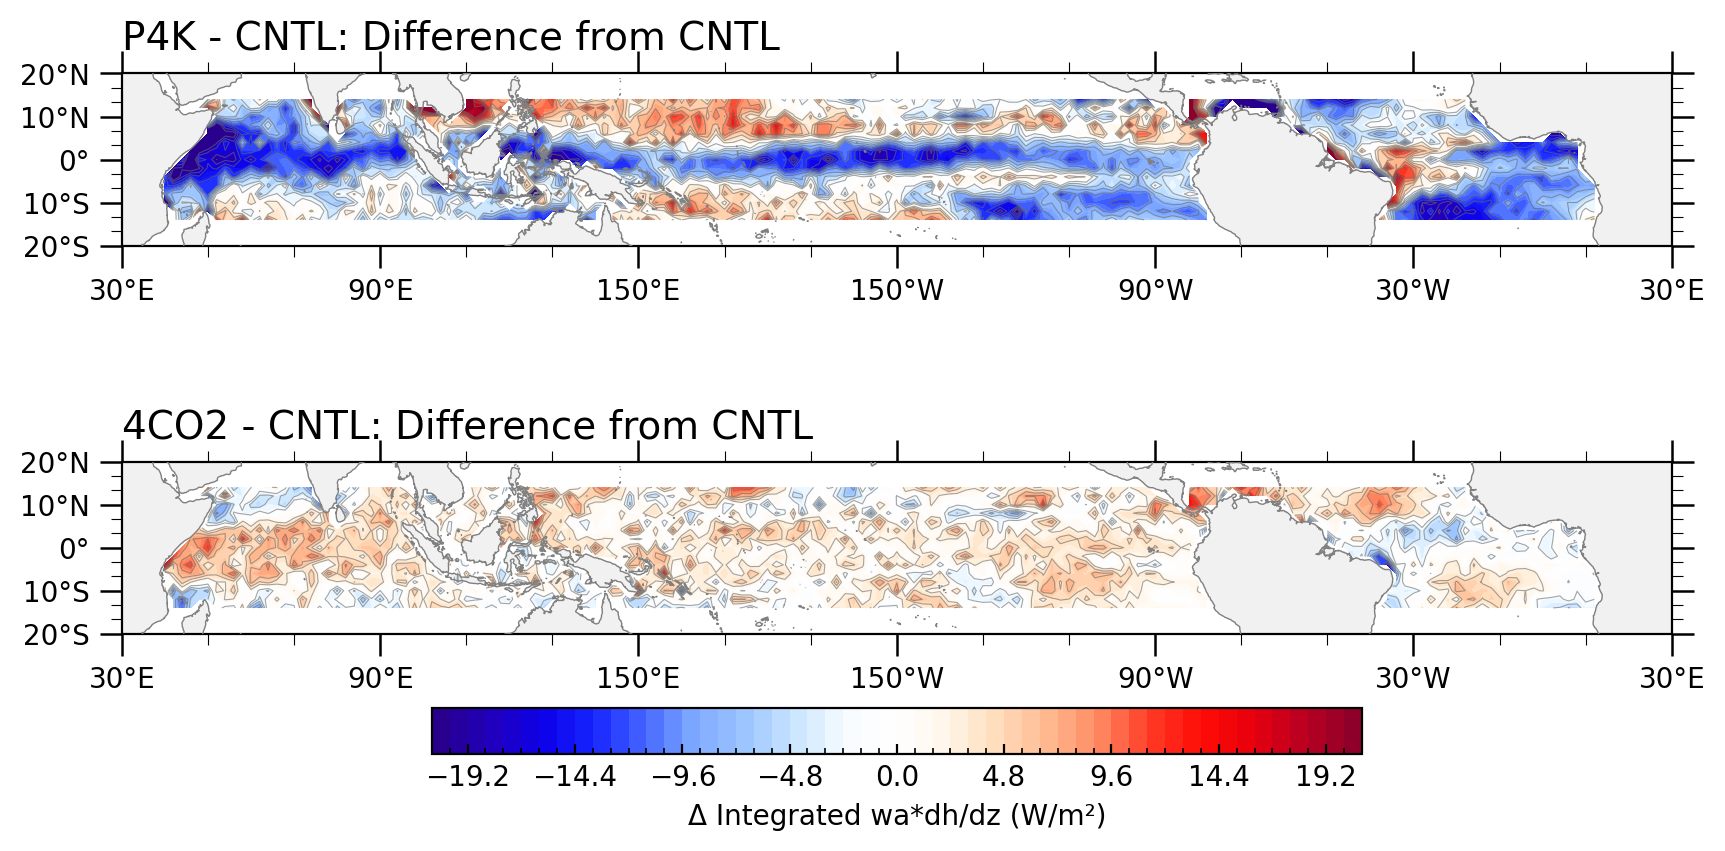

In [34]:

def plot_vadv_difference_maps(data_cntl, data_dict, figsize=(14, 8), vmin=-50, vmax=50,
                               title_suffix='Difference from CNTL',
                               colorbar_label='Δ Integrated wa*dh/dz (W/m²)',
                               save_filename=None):
    """
    绘制相对于CNTL的差异图
    
    参数:
    -----
    data_cntl : xarray.DataArray
        CNTL实验数据，维度为 (lat, lon)
    data_dict : dict
        其他实验数据字典，格式: {'P4K': data_p4k, '4CO2': data_4co2}
    figsize : tuple
        图形尺寸
    vmin, vmax : float
        颜色范围
    title_suffix : str
        子图标题后缀
    colorbar_label : str
        颜色条标签
    save_filename : str, optional
        保存文件名（包含完整路径）
        
    返回:
    -----
    fig : matplotlib.figure.Figure
        图形对象
    """
    import matplotlib.patheffects as PathEffects
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
    
    # 尝试导入 geocat-viz
    try:
        import geocat.viz.util as gvutil
        use_geocat = True
    except ImportError:
        use_geocat = False
    
    # 尝试导入 cmaps
    try:
        import cmaps
        newcmp = cmaps.NCV_blu_red
        
        from matplotlib.colors import LinearSegmentedColormap
        colors_blue = [newcmp[i].colors for i in [5, 20, 35, 50, 65, 85, 95, 110, 125]]
        colors_red = [newcmp[i].colors for i in [135, 150, 165, 180, 200, 210, 220, 235, 250]]
        all_colors = colors_blue + [[1., 1., 1.]] + colors_red
        n_colors = len(all_colors)
        color_positions = np.linspace(0, 1, n_colors)
        custom_cmap = LinearSegmentedColormap.from_list('custom_blue_white_red', 
                                                         list(zip(color_positions, all_colors)),
                                                         N=256)
    except ImportError:
        custom_cmap = 'RdBu_r'
    
    # 计算差异
    diff_dict = {}
    for exp_name, data in data_dict.items():
        diff_dict[exp_name] = data - data_cntl
    
    # 计算子图数量
    n_exp = len(diff_dict)
    nrows = n_exp
    ncols = 1
    
    # 使用中心经度210°的投影
    proj = ccrs.PlateCarree(central_longitude=210)
    fig = plt.figure(figsize=figsize, dpi=200)
    
    levels_fill = np.linspace(vmin, vmax, 51)
    delc = max((vmax - vmin) / 40, 2)
    levels_contour = np.arange(vmin, 0, delc)
    levels_contour = np.append(levels_contour, np.arange(delc, vmax, delc))
    
    ax_list = []
    
    for idx, (exp_name, diff_data) in enumerate(diff_dict.items()):
        ax = fig.add_subplot(nrows, ncols, idx + 1, projection=proj)
        ax_list.append(ax)
        
        if use_geocat:
            try:
                diff_data = gvutil.xr_add_cyclic_longitudes(diff_data, 'lon')
            except:
                pass
        
        # 设置坐标范围和刻度
        if use_geocat:
            try:
                gvutil.set_axes_limits_and_ticks(ax,
                                               xlim=(-180, 180),
                                               ylim=(-20, 20),
                                               xticks=np.arange(-180, 181, 60),
                                               yticks=np.arange(-20, 21, 10))
                gvutil.add_major_minor_ticks(ax, labelsize=10)
                gvutil.add_lat_lon_ticklabels(ax)
            except:
                ax.set_xlim([-60, 40])
                ax.set_ylim([-15, 15])
                ax.set_xticks(np.arange(-60, 41, 20))
                ax.set_yticks(np.arange(-15, 16, 5))
                ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
                ax.yaxis.set_major_formatter(LatitudeFormatter())
        else:
            ax.set_xlim([-60, 40])
            ax.set_ylim([-15, 15])
            ax.set_xticks(np.arange(-60, 41, 20))
            ax.set_yticks(np.arange(-15, 16, 5))
            ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
            ax.yaxis.set_major_formatter(LatitudeFormatter())
        
        # 绘制填色图
        cf = diff_data.plot.contourf(
            ax=ax,
            levels=levels_fill,
            cmap=custom_cmap,
            add_colorbar=False,
            transform=ccrs.PlateCarree(),
            extend='both',
            add_labels=False
        )
        
        # 添加陆地和海岸线
        ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=2, alpha=0.3)
        ax.add_feature(cfeature.COASTLINE, edgecolor='gray', linewidth=0.5, zorder=3)
        
        # 绘制等值线
        if len(levels_contour) > 0:
            contour = diff_data.plot.contour(
                ax=ax,
                levels=levels_contour,
                colors='dimgray',
                alpha=0.6,
                linewidths=0.4,
                linestyles='solid',
                add_labels=False,
                transform=ccrs.PlateCarree()
            )
            
            try:
                pe = [PathEffects.withStroke(linewidth=1.2, foreground="white", alpha=0.8)]
                if hasattr(contour, 'collections'):
                    for collection in contour.collections:
                        collection.set_path_effects(pe)
            except:
                pass
        
        # 设置标题
        title_text = f'{exp_name} - CNTL: {title_suffix}'
        if use_geocat:
            try:
                gvutil.set_titles_and_labels(ax,
                                           lefttitle=title_text,
                                           lefttitlefontsize=14,
                                           righttitle='',
                                           xlabel="",
                                           ylabel="")
            except:
                ax.set_title(title_text, fontsize=14, loc='left')
        else:
            ax.set_title(title_text, fontsize=14, loc='left')
    
    # 添加颜色棒
    cbar = fig.colorbar(cf, ax=ax_list,
                       drawedges=False,
                       orientation='horizontal',
                       shrink=0.6,
                       pad=0.08,
                       extendfrac='auto',
                       extendrect=True,
                       label=colorbar_label)
    
    cbar.ax.tick_params(labelsize=10, direction='in', which='both')

    
    if save_filename:
        plt.savefig(save_filename, dpi=450, bbox_inches='tight')
        print(f"💾 图形已保存: {save_filename}")
    
    return fig

print("\n📈 绘制相对于CNTL的差异图（使用改进的配色方案）...")
data_dict_diff = {
    'P4K':  vadv_mean['mse_vadv_int_p4k'],
    '4CO2': vadv_mean['mse_vadv_int_4co2'],
}
fig2 = plot_vadv_difference_maps(
    data_cntl=vadv_mean['mse_vadv_int_cntl'],
    data_dict=data_dict_diff,
    figsize=(10, 6),
    vmin=-20,
    vmax=20,
    title_suffix='Difference from CNTL',
    colorbar_label='Δ Integrated wa*dh/dz (W/m²)',
    save_filename=fig_save_dir + 'vadv_int_difference_from_cntl_improved.png'
)